# Laboratório 05 — PCA e Detecção de Anomalias

**Base:** Breast Cancer Wisconsin  
**Tempo estimado:** 70–90 minutos

> Este laboratório apresenta PCA e anomalias de forma introdutória.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

cancer = load_breast_cancer(as_frame=True)
X = cancer.data.copy()
y = cancer.target.copy()

## 1. Estrutura da base

In [ ]:
print("Dimensões:", X.shape)
display(X.head())
display(X.describe().T.head(10))

Dimensões: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 2. Padronização

In [ ]:
scaler = StandardScaler()
X_pad = scaler.fit_transform(X)

## 3. PCA com duas componentes

In [ ]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_pad)

df_pca = pd.DataFrame(componentes, columns=["PC1", "PC2"])
df_pca["classe"] = y.map({0: "maligno", 1: "benigno"})

variancia = pca.explained_variance_ratio_
print("Variância explicada:", variancia)
print("Total:", variancia.sum())

Variância explicada: [0.44272026 0.18971182]
Total: 0.6324320765155944


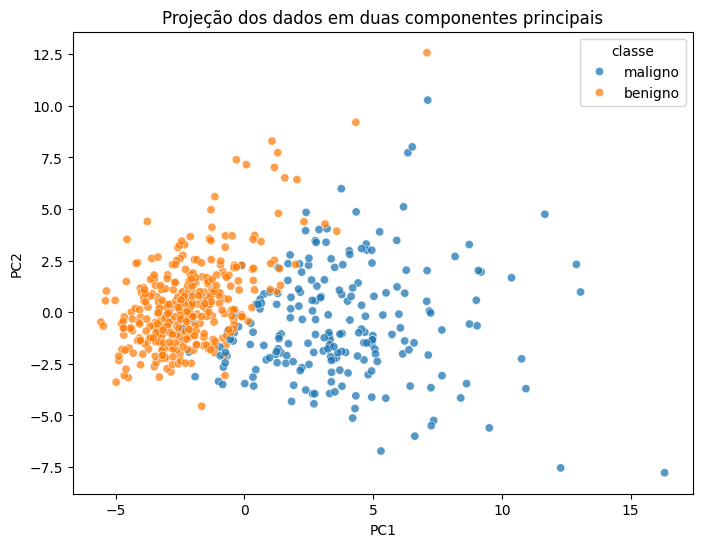

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="classe", alpha=0.75)
plt.title("Projeção dos dados em duas componentes principais")
plt.show()

### Atividade 1
1. Qual percentual de variância é explicado pelas duas componentes?
2. Há separação visual entre as classes?
3. O PCA substitui os atributos originais ou cria novas combinações?

**Resposta:**

1. 63,24% (0.6324320765155944)
2. Sim.
3. O PCA cria novas variáveis (chamadas de componentes principais) que são combinações lineares dos atributos originais.

## 4. Detecção introdutória de anomalias

In [ ]:
detector = IsolationForest(
    contamination=0.03,
    random_state=42
)

anomalia = detector.fit_predict(X_pad)
df_pca["anomalia"] = np.where(anomalia == -1, "Possível anomalia", "Regular")

df_pca["anomalia"].value_counts()

,count
anomalia,
Regular,551
Possível anomalia,18


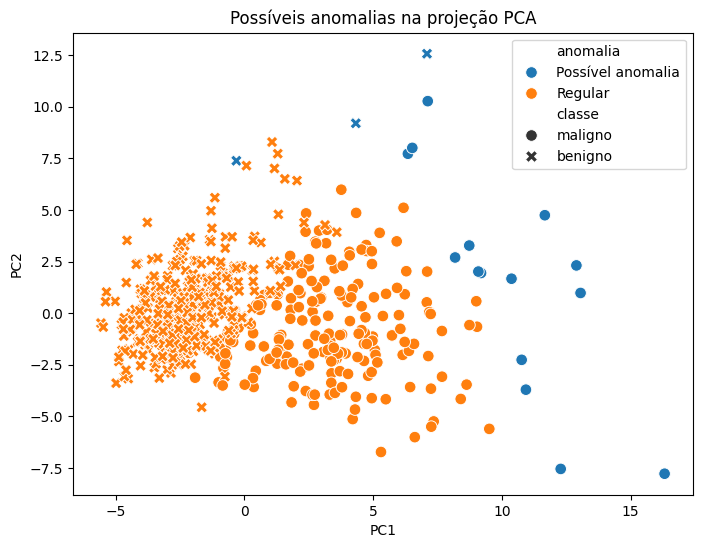

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="anomalia",
    style="classe",
    s=70
)
plt.title("Possíveis anomalias na projeção PCA")
plt.show()

### Atividade 2
Analise os pontos marcados como possíveis anomalias. Eles estão necessariamente errados? Explique a diferença entre **valor atípico**, **erro** e **caso raro**.

**Resposta:**

- Diferença entre Valor Atípico, Erro e Caso Raro
1. Valor Atípico (Outlier): Conceito amplo para qualquer dado que se afasta significativamente do padrão das demais observações. É apenas um alerta estatístico, podendo representar tanto um problema no dado quanto um evento real e legítimo.
2. Erro: Um dado incorreto, gerado por problemas como falhas de digitação, sensores descalibrados, ruído na medição ou bugs no pipeline. Deve ser corrigido ou removido.
3. Caso Raro (ou Anomalia do Mundo Real): Um dado 100% correto e legítimo, mas que reflete um evento atípico da realidade. No contexto médico do dataset de câncer de mama, um ponto atípico pode representar um tumor maligno altamente agressivo, de tamanho fora do comum ou com características morfológicas excepcionais.
- Análise do Gráfico
1. Distribuição dos Pontos: A maioria dos pontos marcados em azul (possíveis anomalias) concentra-se em valores altos da primeira componente principal ($\text{PC1} > 7$) ou extremidades da segunda componente principal ($\text{PC2}$).
2. Importância Clínica: Remover essas anomalias achando que são "erros" seria uma falha grave em aplicações médicas. Casos atípicos costumam carregar as informações mais valiosas para a identificação de quadros clínicos severos ou variantes raras de tumores.

## 5. Inspeção das observações

In [ ]:
indices_anomalias = np.where(anomalia == -1)[0]
X.iloc[indices_anomalias].head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.2776,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
3,11.42,20.38,77.58,386.1,0.14250,0.2839,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
9,12.46,24.04,83.97,475.9,0.11860,0.2396,0.2273,0.08543,0.2030,0.08243,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.2075
12,19.17,24.80,132.40,1123.0,0.09740,0.2458,0.2065,0.11180,0.2397,0.07800,...,20.96,29.94,151.70,1332.0,0.1037,0.3903,0.3639,0.1767,0.3176,0.1023
42,19.07,24.81,128.30,1104.0,0.09081,0.2190,0.2107,0.09961,0.2310,0.06343,...,24.09,33.17,177.40,1651.0,0.1247,0.7444,0.7242,0.2493,0.4670,0.1038


## Entrega
Salve como `LAB05_NomeSobrenome.ipynb` e complete as interpretações.